# Planck PR4 v4.3

In [3]:
import MCtools
import getdist
from getdist import plots, MCSamples
from getdist.mcsamples import loadMCSamples
getdist.chains.print_load_details = False
import warnings
warnings.filterwarnings("ignore")
DBdir = "/sps/planck/Users/tristram/Soft/Hillik/chains_v1"
support={'tau':(0,0.15),'xi':(-1,1),'Aksz':(0,10)}
%matplotlib inline
MCtools.parname.update({p:r'$A_{dust}^{PLK%s}(%s)$' % (p[-5:-2],p[-2:]) for p in ['PLK_Adust100TT','PLK_Adust143TT','PLK_Adust217TT']})
MCtools.parname.update({p:r'$A_{dust}^{PLK%s}(%s)$' % (p[-5:-2],p[-2:]) for p in ['PLK_Adust100TE','PLK_Adust143TE','PLK_Adust217TE']})
MCtools.parname.update({p:r'$A_{dust}^{PLK%s}(%s)$' % (p[-5:-2],p[-2:]) for p in ['PLK_Adust100EE','PLK_Adust143EE','PLK_Adust217EE']})
MCtools.parname.update({p+'_radio_TT':r'$A_{radio}^{%s}$' % (p) for p in ['PLK','ACT','SPT','SPT3G']})
MCtools.parname.update({p+'_cib_ps':r'$A_{IR}^{%s}$' % (p) for p in ['PLK','ACT','SPT','SPT3G']})

### Dust

hillik_plk_TTTEEE: 20001  20001  20001  20001 
hillik_plk_TTTEEE_oldalpha: 60721  62409  71640  72592 
hillik_plk_TTTEEE_alphaPR3: 77798  75681  79079  76960 
hillik_plk_TTTEEE_nodustprior: 87743  79201  82256  88236 
hillik_plk_TTTEEE_dustfix: 57082  57761  58032  61383 
hillik_plk_TTTEEE_alphafree: 115001  125666  125640  124247 


(5, 1)

<Figure size 1000x1000 with 0 Axes>

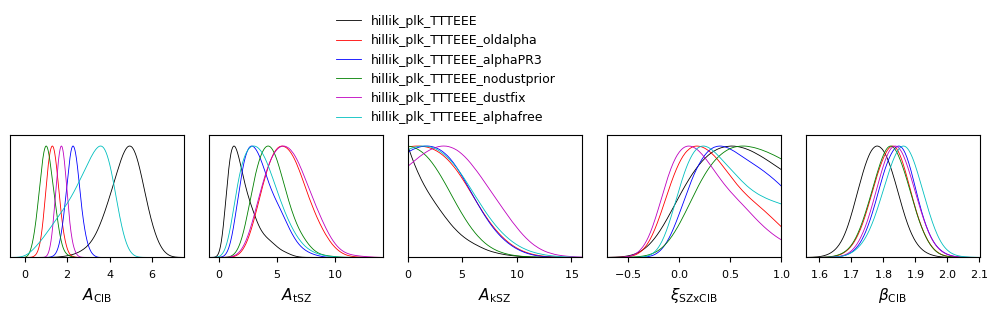

In [13]:
runnames = ['hillik_plk_TTTEEE','hillik_plk_TTTEEE_oldalpha','hillik_plk_TTTEEE_alphaPR3','hillik_plk_TTTEEE_nodustprior','hillik_plk_TTTEEE_dustfix','hillik_plk_TTTEEE_alphafree']
chains = [MCtools.mergeMC( f"{DBdir}/{run}/burn", burnin=-20000) for run in runnames[:1]]
for r in runnames[1:]: chains.append( MCtools.mergeMC( f"{DBdir}/dust/{r}/mcmc", burnin=0.7))
#chains.append( MCtools.mergeMC( f"{DBdir}_uniqdust/hillik_plk_TTTEEE/burn", burnin=-40000))
#runnames.append( 'hillik_plk_TTTEEE_uniqdust')
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
labels = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
parnames = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=parnames, ranges={'Aksz':[0,16],'xi':[-1,1]}) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.plots_1d(samples, listpar, nx=5, legend_labels=runnames)

(6, 1)

<Figure size 1200x1200 with 0 Axes>

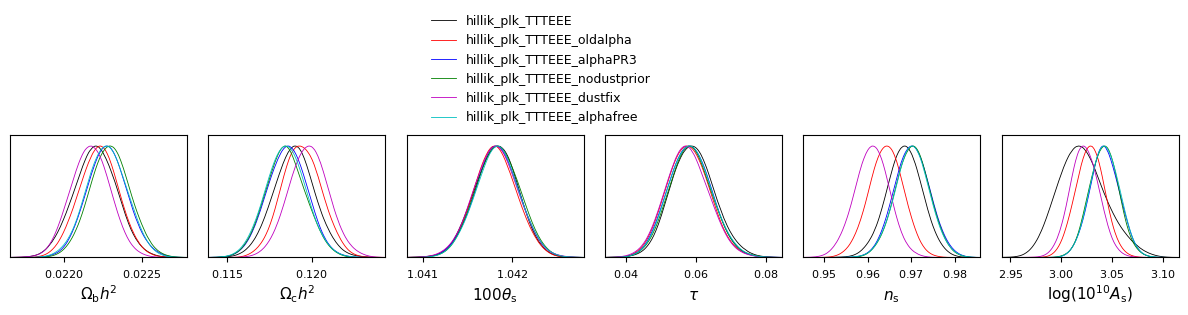

In [5]:
#for chain in chains[:-1]: 
#    for k,v in {'ombh2':'omegabh2','omch2':'omegach2'}.items(): chain[k] = chain[v] 
#    chain['theta'] = chain['theta_s_100']
#listpar = ['ombh2','omch2','theta','tau','ns','logA']
listpar = ['omegabh2','omegach2','theta_s_100','tau','ns','logA']
labels = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
parnames = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=parnames) for chain in chains]
g = plots.getSinglePlotter(width_inch=12,ratio=1)
g.plots_1d(samples, listpar, nx=6, legend_labels=runnames)

(6, 1)

<Figure size 1500x1500 with 0 Axes>

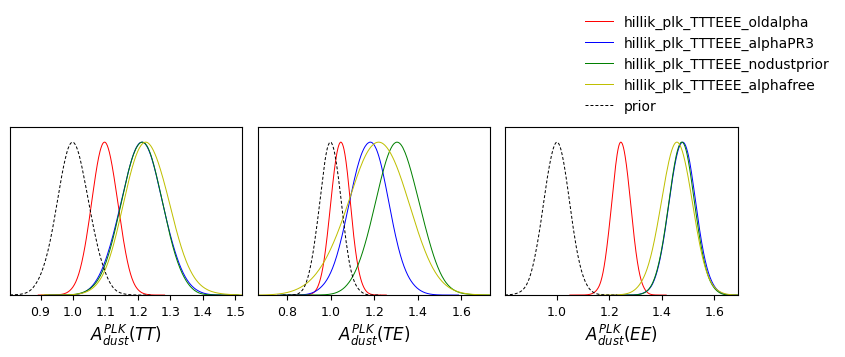

In [6]:
listpar = ['PLK_AdustTT', 'PLK_AdustTE', 'PLK_AdustEE']
parnames = ['A_{dust}^{PLK}(%s)' % p[-2:] for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=parnames) for chain in chains if 'PLK_AdustTT' in chain]
prior   = [MCSamples( samples=[np.random.randn(10000)*0.05+1. for p in listpar], names=listpar, labels=listpar)]
g = plots.getSinglePlotter(width_inch=15,ratio=1)
g.plots_1d(samples+prior, listpar, nx=6, legend_labels=[runnames[i] for i in range(len(runnames)) if 'PLK_AdustTT' in chains[i]]+['prior'], colors=['r','b','g','y'][:len(samples)]+['k'], ls=['-']*len(samples)+['--'])

(4, 1)

<Figure size 1200x1200 with 0 Axes>

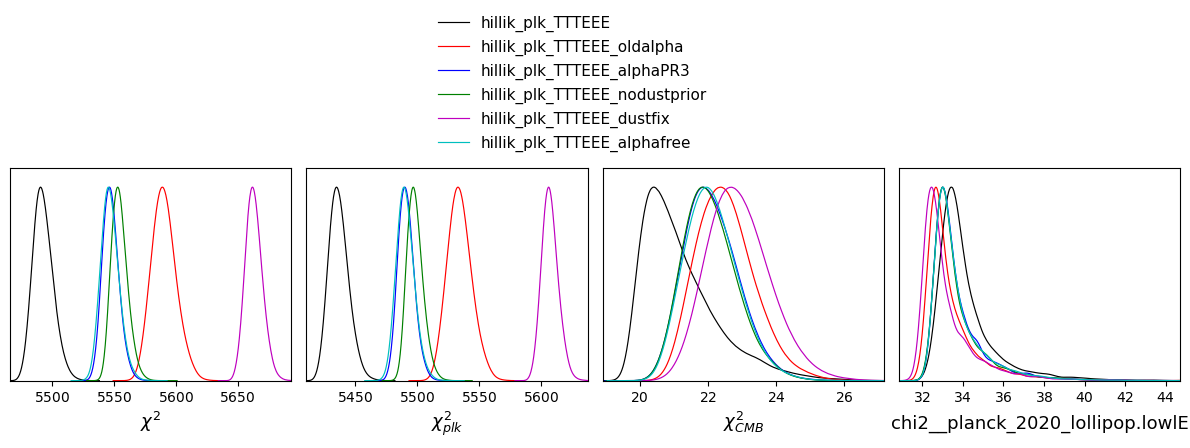

In [26]:
listpar = ['chi2','chi2__hillik_planck.TTTEEE','chi2__planck_2018_lowl.TT','chi2__planck_2020_lollipop.lowlE']
labels = ['\chi^2','\chi^2_{plk}','\chi^2_{CMB}']
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=labels) for chain in chains]
g = plots.getSinglePlotter(width_inch=12,ratio=1)
g.plots_1d(samples, listpar, nx=len(listpar), legend_labels=runnames)

hillik_plk_TTTEEE_alphafree: 20001  20001  20001  20001 
hillik_plk_TTTEEE_alphaprior: 20001  20001  20001  20001 
hillik_plk_TTTEEE_nodustprior: 20001  20001  20001  20001 


<Figure size 1000x1000 with 0 Axes>

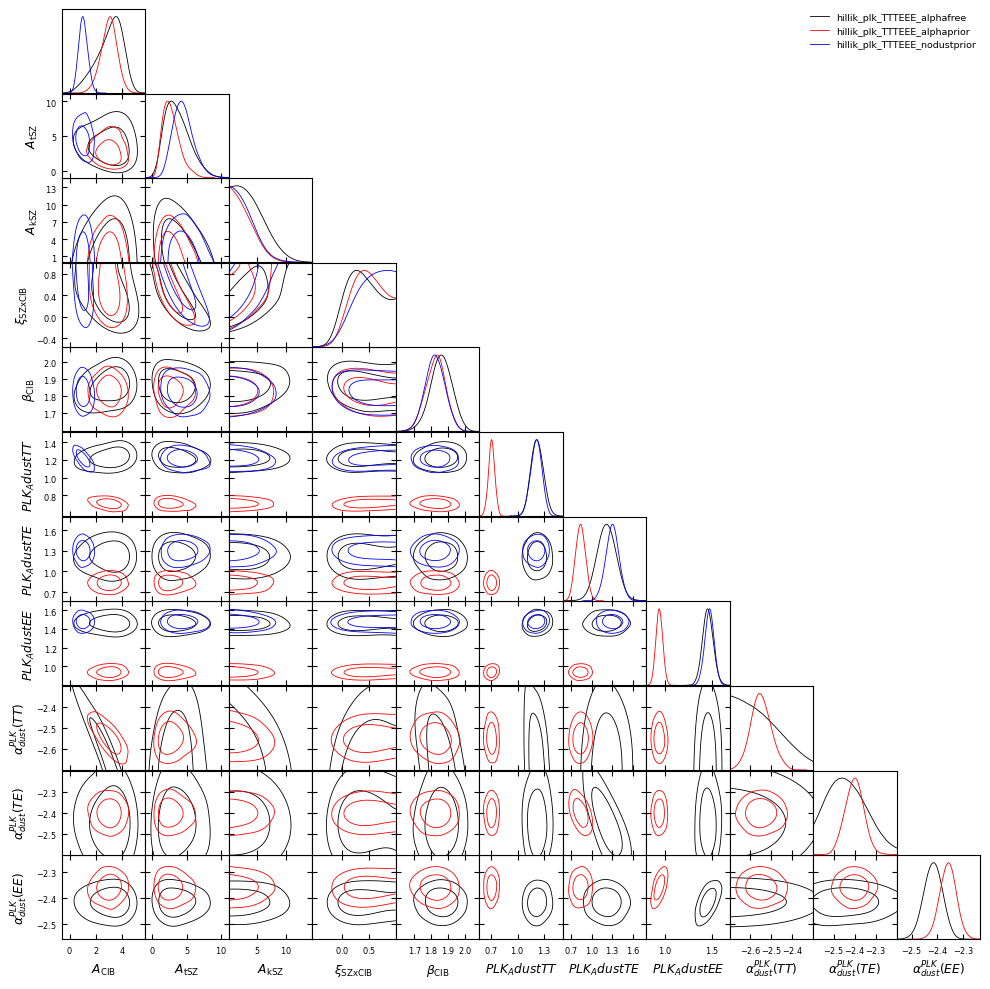

In [8]:
runnames = ['hillik_plk_TTTEEE_alphafree','hillik_plk_TTTEEE_alphaprior','hillik_plk_TTTEEE_nodustprior']
chains = [ MCtools.mergeMC( f"{DBdir}/dust/{run}/burn", burnin=0.7) for run in runnames]
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib','PLK_AdustTT', 'PLK_AdustTE', 'PLK_AdustEE','PLK_alphaTT','PLK_alphaTE','PLK_alphaEE']
support = {'Aksz':[0,16],'xi':[-1,1],'PLK_alphaTT':[-2.7,-2.3],'PLK_alphaTE':[-2.6,-2.2],'PLK_alphaEE':[-2.6,-2.2]}
MCtools.parname.update({p:r'\alpha_{dust}^{PLK}(%s)' % p[-2:] for p in ['PLK_alphaTT','PLK_alphaTE','PLK_alphaEE']})
samples = [MCSamples( samples=[chain[p] for p in listpar if p in chain], names=[p for p in listpar if p in chain], labels=[MCtools.parname.get(p,p).replace('$','') for p in listpar if p in chain], ranges=support) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, legend_labels=runnames, legend_loc='upper right')

<Figure size 1000x1000 with 0 Axes>

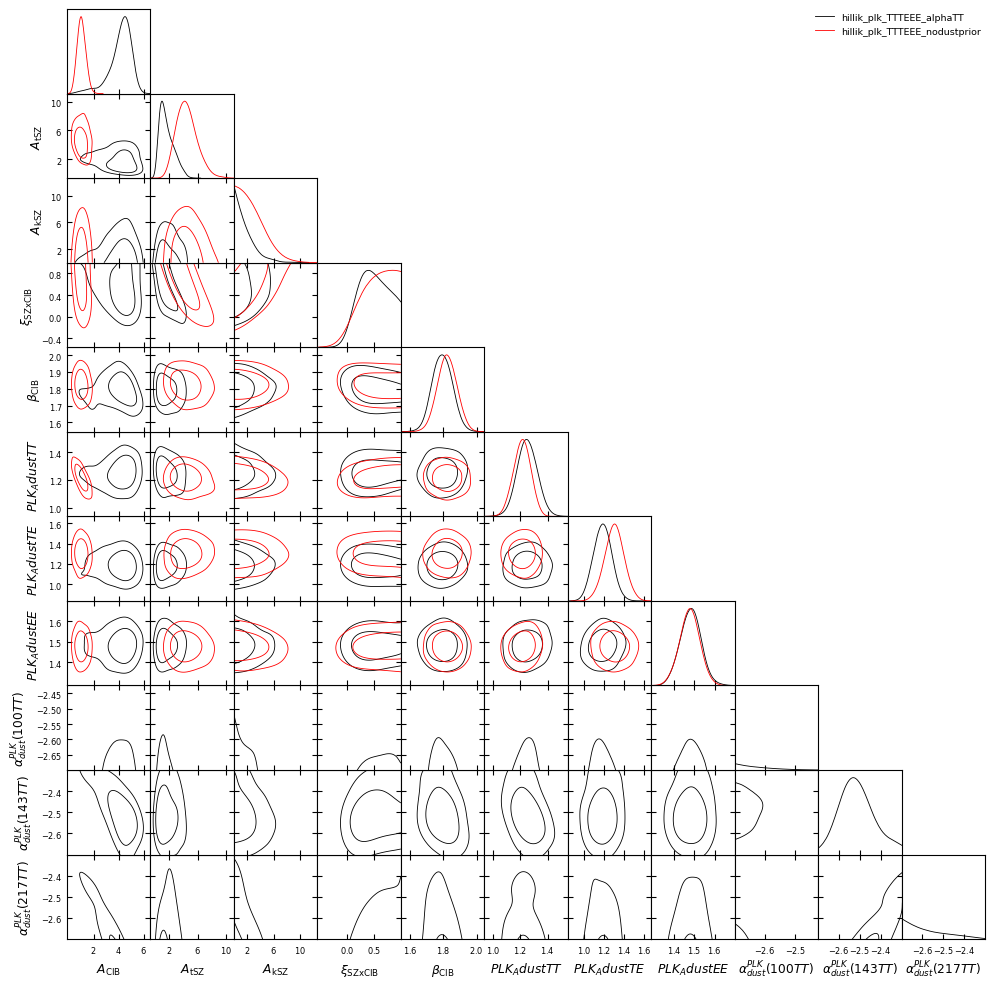

In [12]:
runnames = ['hillik_plk_TTTEEE_alphaTT','hillik_plk_TTTEEE_nodustprior']
chains = [ MCtools.mergeMC( f"{DBdir}/dust/{run}/burn", burnin=0.7) for run in runnames]
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib','PLK_AdustTT', 'PLK_AdustTE', 'PLK_AdustEE','PLK_alpha_dust100TT','PLK_alpha_dust143TT','PLK_alpha_dust217TT']
support = {'Aksz':[0,16],'xi':[-1,1],'PLK_alpha_dust100TT':[-2.7,-2.3],'PLK_alpha_dust143TT':[-2.7,-2.3],'PLK_alpha_dust217TT':[-2.7,-2.3]}
MCtools.parname.update({p:r'\alpha_{dust}^{PLK}(%s)' % p[-5:] for p in ['PLK_alpha_dust100TT','PLK_alpha_dust143TT','PLK_alpha_dust217TT']})
samples = [MCSamples( samples=[chain[p] for p in listpar if p in chain], names=[p for p in listpar if p in chain], labels=[MCtools.parname.get(p,p).replace('$','') for p in listpar if p in chain], ranges=support) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, legend_labels=runnames, legend_loc='upper right')

## Correlations

hillik_plk_TTTEEE: 461023  460801  464031  464638 
logA =  3.02052 +/- 0.02600


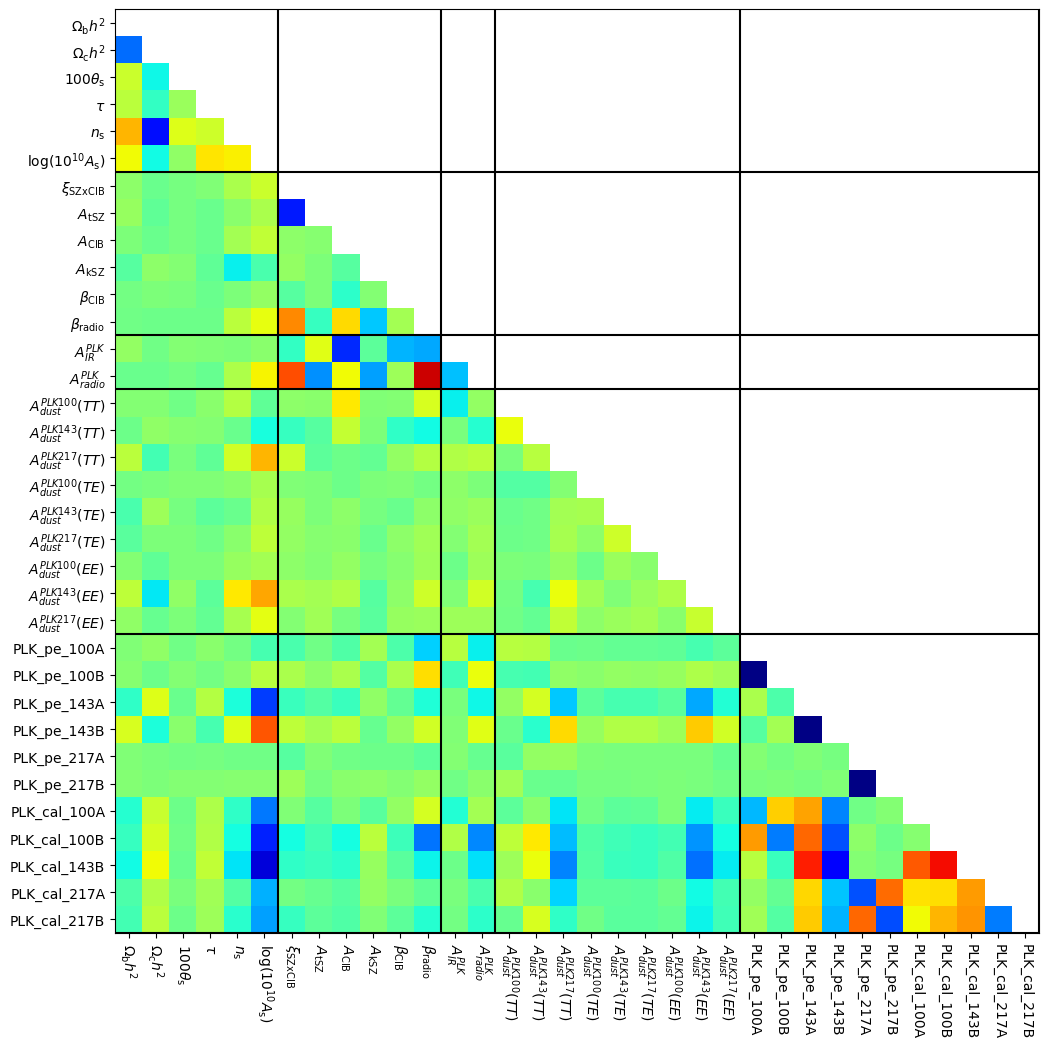

In [27]:
runname = 'hillik_plk_TTTEEE'
chain = MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,runname), burnin=-20000)
pars_cosmo = ['omegabh2','omegach2','theta_s_100','tau','ns','logA']
pars_exgal = ['xi','Atsz','Acib','Aksz','beta_cib','beta_radio']
pars_ps = ['PLK_cib_ps','PLK_radio_TT']
pars_galfg = ['PLK_Adust100TT','PLK_Adust143TT','PLK_Adust217TT',
              'PLK_Adust100TE','PLK_Adust143TE','PLK_Adust217TE',
              'PLK_Adust100EE','PLK_Adust143EE','PLK_Adust217EE']
pars_cal   = [p for p in chain.keys() if "cal" in p or "pe" in p]
fig = plt.figure(figsize=(12,12))
corr = MCtools.MCcorrelation( chain, pars_cosmo+pars_exgal+pars_ps+pars_galfg+pars_cal, plot=True)
icol = [len(p) for p in [pars_cosmo,pars_exgal,pars_ps,pars_galfg,pars_cal]]
for p in np.cumsum(icol): plt.axvline( p-0.5, color='k')
for p in np.cumsum(icol): plt.axhline( p-0.5, color='k')
MCtools.PrintMean( chain, ['logA'])